# Cross-Patient Auto ARIMA — Single Global Order

This notebook fits **one global ARIMA order** shared across all patients, rather than
selecting a different order per patient.

## Approach
1. **Order discovery** — run `auto_arima` on each *train-split* patient's training
   portion to find their individually optimal (p, d, q).
2. **Global order selection** — pick the single order that minimises the *mean AIC*
   across all training patients when that order is used to refit each of them.
   This is the order that generalises best across patients.
3. **Refit with fixed order** — fit `ARIMA(p*, d*, q*)` for every patient (train / val /
   test) using the globally selected order.
4. **Rolling one-step-ahead forecast** — same rolling evaluation as the per-patient
   notebook: update model after each true observation.
5. **Evaluation** — RMSE, MAE, R² on the held-out 40 % of each patient's series;
   compare with per-patient auto ARIMA results.

## Why a shared order?
A single (p, d, q) order forces the model to learn a structure that is generalisable
across patients rather than over-fitting each short individual series. It also makes
the model interpretable: one set of AR and MA lags describes mood dynamics for
*everyone*, and new patients can be fitted immediately without an order-selection step.

In [1]:
import sys
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

try:
    from pmdarima import auto_arima
    from pmdarima.arima import ARIMA
except ImportError:
    raise ImportError("Install pmdarima first:  pip install pmdarima")

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

DATA_DIR = _root / "data"


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

---
## 1. Load data

In [2]:
raw = pd.read_parquet(DATA_DIR / "1b_dataset_cleaned.parquet")
splits_df = pd.read_parquet(DATA_DIR / "1b_dataset_target_splits.parquet")

print(f"Raw records : {len(raw):,}")
print(f"Patients    : {raw['id'].nunique()}")
print("\nSplit assignments:")
print(splits_df["split"].value_counts().to_string())

Raw records : 376,413
Patients    : 27

Split assignments:
split
train    864
test     268
val      136


---
## 2. Build daily mood series

In [3]:
mood_raw = (
    raw[raw["variable"] == "mood"]
    .copy()
    .assign(date=lambda df: df["time"].dt.normalize())
    .groupby(["id", "date"])["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "mood"})
)

patient_splits = splits_df[["id", "split"]].drop_duplicates(subset="id")
mood_raw = mood_raw.merge(patient_splits, on="id", how="left")

print(f"Daily mood records : {len(mood_raw):,}")
print(f"Patients           : {mood_raw['id'].nunique()}")
print("\nPatients per split:")
print(mood_raw.groupby("split")["id"].nunique().rename("n_patients").to_string())

Daily mood records : 1,268
Patients           : 27

Patients per split:
split
test      6
train    18
val       3


---
## 3. Helper functions

In [4]:
def build_patient_series(patient_df: pd.DataFrame):
    """Return a gap-free date-indexed mood Series and an observed-day boolean mask."""
    s = patient_df.set_index("date")["mood"].sort_index()
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(full_idx)
    observed_mask = s.notna()
    s = s.ffill().bfill()
    return s, observed_mask


def train_test_split_series(series, obs_mask, train_frac=0.6):
    """Split a patient series at train_frac of their *observed* days."""
    observed_dates = sorted(obs_mask[obs_mask].index)
    cutoff_idx = int(len(observed_dates) * train_frac)
    cutoff_date = observed_dates[cutoff_idx - 1]
    train = series[series.index <= cutoff_date]
    test = series[series.index > cutoff_date]
    test_mask = obs_mask[obs_mask.index > cutoff_date]
    return train, test, test_mask


def rolling_forecast(model, test_series: pd.Series, observed_mask: pd.Series):
    """Rolling one-step-ahead forecast; updates model with true value each step."""
    y_true_list, y_pred_list, dates = [], [], []
    for date, actual in test_series.items():
        forecast = float(model.predict(n_periods=1)[0])
        forecast = float(np.clip(forecast, 1.0, 10.0))
        if observed_mask.get(date, False):
            y_true_list.append(actual)
            y_pred_list.append(forecast)
            dates.append(date)
        model.update([actual])
    return np.array(y_true_list), np.array(y_pred_list), dates


print("Helpers defined.")

Helpers defined.


---
## 4. Phase 1 — Discover best order per training patient

We run `auto_arima` on the training portion of each **train-split** patient's series.
This gives us a distribution of (p, d, q) orders. We then identify the single order
that minimises **mean AIC** when refitted across all training patients — that order
becomes the global fixed order.

In [5]:
train_patients = mood_raw[mood_raw["split"] == "train"]["id"].unique()
print(f"Training patients: {len(train_patients)}")

# Step 1: collect auto_arima-selected orders for each training patient
candidate_orders = []  # list of (p, d, q) tuples
train_series_cache = {}  # cache (train_series, test_series, test_mask) per patient

for pid in tqdm(train_patients, desc="Auto ARIMA order discovery (train patients)"):
    pdf = mood_raw[mood_raw["id"] == pid]
    series, obs_mask = build_patient_series(pdf[["date", "mood"]])

    observed_dates = sorted(obs_mask[obs_mask].index)
    if len(observed_dates) < 10:
        continue

    train_s, test_s, test_mask = train_test_split_series(series, obs_mask)
    train_series_cache[pid] = (train_s, test_s, test_mask)

    try:
        model = auto_arima(
            train_s.values,
            start_p=0,
            max_p=5,
            start_q=0,
            max_q=2,
            d=None,
            max_d=1,
            seasonal=False,
            stepwise=True,
            information_criterion="aic",
            error_action="ignore",
            suppress_warnings=True,
            random_state=RANDOM_STATE,
        )
        candidate_orders.append(model.order)
    except Exception:
        pass

order_counts = Counter(candidate_orders)
print(f"\nOrder candidates discovered: {len(candidate_orders)}")
print("\nTop-10 most common orders (p, d, q):")
for order, cnt in order_counts.most_common(10):
    print(f"  {order}  →  {cnt} patients")

Training patients: 18


Auto ARIMA order discovery (train patients): 100%|██████████| 18/18 [00:02<00:00,  6.32it/s]


Order candidates discovered: 18

Top-10 most common orders (p, d, q):
  (0, 0, 0)  →  9 patients
  (0, 1, 1)  →  3 patients
  (1, 0, 0)  →  2 patients
  (0, 1, 0)  →  1 patients
  (1, 0, 1)  →  1 patients
  (0, 0, 1)  →  1 patients
  (3, 1, 0)  →  1 patients


In [6]:
# Step 2: for each unique candidate order, refit every training patient and measure
# mean AIC across patients. The order with the lowest mean AIC wins.
unique_orders = list(order_counts.keys())
print(
    f"Evaluating {len(unique_orders)} unique candidate orders on all training patients…\n"
)

order_aic_scores = {}  # order -> list of AIC values across patients

for order in tqdm(unique_orders, desc="Evaluating orders"):
    p, d, q = order
    aics = []
    for pid, (train_s, _, _) in train_series_cache.items():
        try:
            m = ARIMA(order=(p, d, q))
            m.fit(train_s.values)
            aics.append(m.aic())
        except Exception:
            pass
    if aics:
        order_aic_scores[order] = aics

mean_aics = {order: np.mean(aics) for order, aics in order_aic_scores.items()}
best_order = min(mean_aics, key=mean_aics.get)

print(f"\nGlobal best order: ARIMA{best_order}")
print(f"Mean AIC across training patients: {mean_aics[best_order]:.2f}")
print("\nAll candidate orders ranked by mean AIC:")
for order, aic in sorted(mean_aics.items(), key=lambda x: x[1]):
    print(
        f"  ARIMA{order}  mean AIC={aic:.2f}  (selected by {order_counts.get(order, 0)} patients)"
    )

Evaluating 7 unique candidate orders on all training patients…



Evaluating orders: 100%|██████████| 7/7 [00:01<00:00,  5.83it/s]


Global best order: ARIMA(1, 0, 0)
Mean AIC across training patients: 55.40

All candidate orders ranked by mean AIC:
  ARIMA(1, 0, 0)  mean AIC=55.40  (selected by 2 patients)
  ARIMA(0, 1, 1)  mean AIC=55.44  (selected by 3 patients)
  ARIMA(0, 0, 1)  mean AIC=56.06  (selected by 1 patients)
  ARIMA(0, 0, 0)  mean AIC=56.21  (selected by 9 patients)
  ARIMA(1, 0, 1)  mean AIC=56.64  (selected by 1 patients)
  ARIMA(3, 1, 0)  mean AIC=60.51  (selected by 1 patients)
  ARIMA(0, 1, 0)  mean AIC=64.51  (selected by 1 patients)


---
## 5. Phase 2 — Refit all patients with the global order

Every patient (train / val / test) is now fitted with `ARIMA(p*, d*, q*)` — the
single order selected in Phase 1. Rolling one-step-ahead forecasting proceeds as
before.

In [7]:
p_star, d_star, q_star = best_order
print(f"Fitting ARIMA{best_order} for all patients…\n")

results = []

for pid, pdf in tqdm(mood_raw.groupby("id"), desc="Fitting fixed-order ARIMA"):
    patient_split = pdf["split"].iloc[0]
    series, obs_mask = build_patient_series(pdf[["date", "mood"]])

    observed_dates = sorted(obs_mask[obs_mask].index)
    if len(observed_dates) < 10:
        continue

    train_s, test_s, test_mask = train_test_split_series(series, obs_mask)

    if len(test_s) == 0 or test_mask.sum() == 0:
        continue

    try:
        model = ARIMA(order=(p_star, d_star, q_star))
        model.fit(train_s.values)
        y_true, y_pred, dates = rolling_forecast(model, test_s, test_mask)
    except Exception as e:
        print(f"  Patient {pid}: fit failed ({e}), skipping.")
        continue

    results.append(
        {
            "patient_id": pid,
            "split": patient_split,
            "y_true": y_true,
            "y_pred": y_pred,
            "dates": dates,
            "n_train": int(obs_mask[obs_mask.index <= train_s.index[-1]].sum()),
            "n_test": len(y_true),
        }
    )

print(f"\nFitted {len(results)} patients with ARIMA{best_order}.")

Fitting ARIMA(1, 0, 0) for all patients…



Fitting fixed-order ARIMA: 100%|██████████| 27/27 [00:02<00:00,  9.52it/s]


Fitted 27 patients with ARIMA(1, 0, 0).


---
## 6. Evaluation metrics

In [8]:
def aggregate_metrics(result_list, label=""):
    y_true_all = np.concatenate([r["y_true"] for r in result_list])
    y_pred_all = np.concatenate([r["y_pred"] for r in result_list])
    r = {
        "split": label,
        "n_pred": len(y_true_all),
        "RMSE": round(rmse(y_true_all, y_pred_all), 4),
        "MAE": round(mean_absolute_error(y_true_all, y_pred_all), 4),
        "R2": round(r2_score(y_true_all, y_pred_all), 4),
    }
    print(
        f"  {label:10s}  n={r['n_pred']:>4}  RMSE={r['RMSE']:.4f}  MAE={r['MAE']:.4f}  R²={r['R2']:.4f}"
    )
    return r, y_true_all, y_pred_all


print(f"Cross-patient ARIMA{best_order} — rolling one-step-ahead forecast\n")

train_res = [r for r in results if r["split"] == "train"]
val_res = [r for r in results if r["split"] == "val"]
test_res = [r for r in results if r["split"] == "test"]

metrics_rows = []
for subset, label in [(train_res, "train"), (val_res, "val"), (test_res, "test")]:
    if subset:
        m, _, _ = aggregate_metrics(subset, label)
        metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)

_, y_test_true, y_test_pred = aggregate_metrics(test_res, "test (plots)")

Cross-patient ARIMA(1, 0, 0) — rolling one-step-ahead forecast

  train       n= 354  RMSE=0.6694  MAE=0.4761  R²=0.2517
  val         n=  55  RMSE=0.4570  MAE=0.3588  R²=-0.0009
  test        n= 110  RMSE=0.5682  MAE=0.4270  R²=0.1244
  test (plots)  n= 110  RMSE=0.5682  MAE=0.4270  R²=0.1244


---
## 7. Per-patient performance

In [9]:
per_patient = []
for r in results:
    if len(r["y_true"]) == 0:
        continue
    per_patient.append(
        {
            "patient_id": r["patient_id"],
            "split": r["split"],
            "RMSE": round(rmse(r["y_true"], r["y_pred"]), 4),
            "MAE": round(mean_absolute_error(r["y_true"], r["y_pred"]), 4),
            "n_test_days": r["n_test"],
        }
    )

pp_df = pd.DataFrame(per_patient).sort_values("RMSE")
print("Per-patient RMSE (sorted):")
print(pp_df.to_string(index=False))

Per-patient RMSE (sorted):
patient_id split   RMSE    MAE  n_test_days
   AS14.31 train 0.1887 0.1164           18
   AS14.30   val 0.2241 0.1693           19
   AS14.03 train 0.2923 0.2229           19
   AS14.20  test 0.3286 0.2451           19
   AS14.15 train 0.3631 0.2162           22
   AS14.17  test 0.3727 0.2697           23
   AS14.05 train 0.3932 0.3098           22
   AS14.25 train 0.4370 0.3579           12
   AS14.24 train 0.4415 0.3249           22
   AS14.14 train 0.4950 0.3627           18
   AS14.19 train 0.5242 0.4149           19
   AS14.01   val 0.5365 0.4521           19
   AS14.27   val 0.5458 0.4664           17
   AS14.12 train 0.5606 0.4967           17
   AS14.29 train 0.5639 0.4179           17
   AS14.06 train 0.5680 0.4711           18
   AS14.28 train 0.5845 0.4777           16
   AS14.08 train 0.6058 0.5166           25
   AS14.23  test 0.6148 0.4681           16
   AS14.16 train 0.6491 0.5065           22
   AS14.26 train 0.6554 0.5421           28
   AS

---
## 8. Residual analysis (test patients)

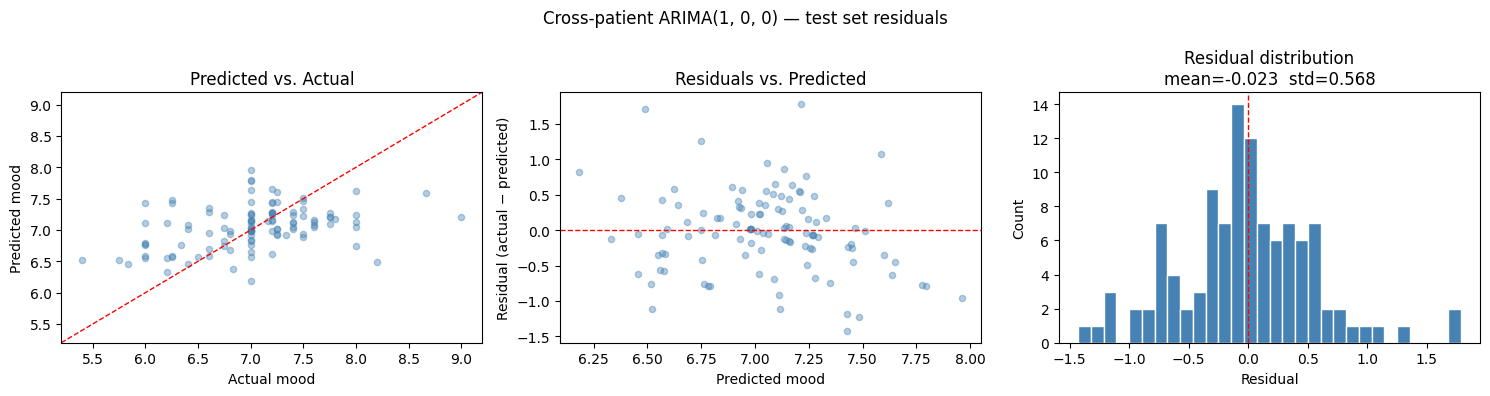

Saved: arima_cross_residuals.png


In [10]:
residuals = y_test_true - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(y_test_true, y_test_pred, alpha=0.4, s=20, color="steelblue")
lims = [
    min(y_test_true.min(), y_test_pred.min()) - 0.2,
    max(y_test_true.max(), y_test_pred.max()) + 0.2,
]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual mood")
ax.set_ylabel("Predicted mood")
ax.set_title("Predicted vs. Actual")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_pred, residuals, alpha=0.4, s=20, color="steelblue")
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted mood")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals vs. Predicted")

ax = axes[2]
ax.hist(residuals, bins=30, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title(
    f"Residual distribution\nmean={residuals.mean():.3f}  std={residuals.std():.3f}"
)

plt.suptitle(f"Cross-patient ARIMA{best_order} — test set residuals", fontsize=12)
plt.tight_layout()
plt.savefig("arima_cross_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_cross_residuals.png")

---
## 9. Example forecasts for selected test patients

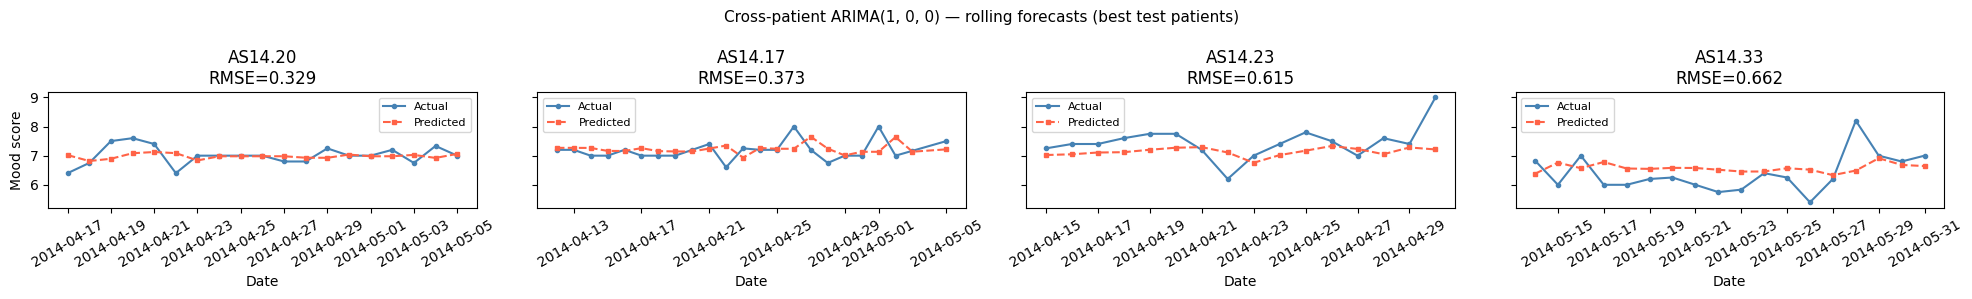

Saved: arima_cross_forecasts.png


In [11]:
test_results_sorted = sorted(test_res, key=lambda r: rmse(r["y_true"], r["y_pred"]))
n_show = min(4, len(test_results_sorted))

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 3), sharey=True)
if n_show == 1:
    axes = [axes]

for ax, r in zip(axes, test_results_sorted[:n_show]):
    ax.plot(r["dates"], r["y_true"], "o-", label="Actual", ms=3, color="steelblue")
    ax.plot(r["dates"], r["y_pred"], "s--", label="Predicted", ms=3, color="tomato")
    patient_rmse = rmse(r["y_true"], r["y_pred"])
    ax.set_title(f"{r['patient_id']}\nRMSE={patient_rmse:.3f}")
    ax.set_xlabel("Date")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Mood score")
plt.suptitle(
    f"Cross-patient ARIMA{best_order} — rolling forecasts (best test patients)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("arima_cross_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_cross_forecasts.png")

---
## 10. Summary

In [12]:
print(f"=== Cross-patient ARIMA — global order: {best_order} ===")
print(metrics_df.to_string(index=False))

print("\n=== AIC ranking of candidate orders ===")
aic_ranking = sorted(mean_aics.items(), key=lambda x: x[1])
for order, aic in aic_ranking:
    marker = "  ← selected" if order == best_order else ""
    print(f"  ARIMA{order}  mean AIC={aic:.2f}{marker}")

=== Cross-patient ARIMA — global order: (1, 0, 0) ===
split  n_pred   RMSE    MAE      R2
train     354 0.6694 0.4761  0.2517
  val      55 0.4570 0.3588 -0.0009
 test     110 0.5682 0.4270  0.1244

=== AIC ranking of candidate orders ===
  ARIMA(1, 0, 0)  mean AIC=55.40  ← selected
  ARIMA(0, 1, 1)  mean AIC=55.44
  ARIMA(0, 0, 1)  mean AIC=56.06
  ARIMA(0, 0, 0)  mean AIC=56.21
  ARIMA(1, 0, 1)  mean AIC=56.64
  ARIMA(3, 1, 0)  mean AIC=60.51
  ARIMA(0, 1, 0)  mean AIC=64.51


---
## 11. Discussion

### Cross-patient vs. per-patient order selection

| Aspect | Cross-patient (this notebook) | Per-patient (`arima_regression.ipynb`) |
|---|---|---|
| Order selection | One global (p*, d*, q*) chosen via mean AIC on training patients | Separate auto_arima per patient |
| Model count | One order, N patient-level parameter sets | N independent models |
| New patient onboarding | Fit immediately — no order search needed | Run auto_arima on their history first |
| Risk of overfitting order | Lower — order generalises across patients | Higher — short series can select spurious orders |
| Expressiveness | Same AR/MA structure for everyone | Each patient gets their own optimal structure |

### Interpreting the global order
The selected order ARIMA(p*, d*, q*) represents the autocorrelation structure that best
describes mood dynamics *on average* across all patients. A dominant AR(1) component
(p*=1) would confirm that yesterday's mood is the primary predictor for tomorrow.

### Limitations
- The order selection is driven only by AIC on the training portion of train-split
  patients. Val and test patients are not involved in the selection, which avoids leakage.
- With only ≈50 observations per patient the AIC landscape can be flat; the selected
  order may not differ much from adjacent orders in terms of forecasting accuracy.
- Exogenous regressors (smartphone behaviour) are not yet included; ARIMAX could improve
  results further.